# Actividad 2 — Lectura · MIDAGRI

**Fuente:** `sources/midagri/Sisagri_2016_2025.xlsx`  
**Institución:** Ministerio de Desarrollo Agrario y Riego (MIDAGRI) — Sistema SISAGRI  

## Objetivo
Leer el archivo Excel de producción agrícola, identificar su estructura interna (hojas, columnas, tipos de datos) y hacer una primera inspección del contenido **sin modificar nada**.

## Regla de esta actividad
> **Ver sin tocar.** No se filtra, no se renombra, no se imputan valores. Todo problema encontrado se documenta para las Actividades 4 y 5.


### Configuración inicial
Carga el `pipeline_config.json` generado en la Actividad 1 y las librerías necesarias.


In [1]:
import os, sys, json, glob, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Asegurar raiz del proyecto
while not os.path.exists('pipeline/config/pipeline_config.json'):
    os.chdir('..')

with open('pipeline/config/pipeline_config.json', 'r', encoding='utf-8') as f:
    CONFIG = json.load(f)

SOURCES = CONFIG['sources']
OUTPUT  = CONFIG['output']
print('Config cargado correctamente.')
print('Raiz del proyecto:', os.getcwd())


Config cargado correctamente.
Raiz del proyecto: C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-


## 2.1 Lectura del archivo Excel


In [2]:
# ============================================================
# 2.1 Lectura del archivo Excel
# ============================================================
path_midagri = SOURCES['midagri']

# Identificar hojas disponibles
xl = pd.ExcelFile(path_midagri)
print('Archivo:', path_midagri)
print('Hojas disponibles:', xl.sheet_names)
print()

# Leer la primera hoja (hoja principal de datos)
df_midagri = pd.read_excel(path_midagri, sheet_name=0)
print('Shape:', df_midagri.shape)
print()
print('Columnas originales:')
for i, col in enumerate(df_midagri.columns):
    print(f'  [{i:02d}] {col} — dtype: {df_midagri[col].dtype}')


Archivo:

 sources/midagri/Sisagri_2016_2025.xlsx
Hojas disponibles: ['2016_2020', '2021_2025']



Shape: (818683, 10)

Columnas originales:
  [00] anho — dtype: int64
  [01] mes — dtype: int64
  [02] COD_UBIGEO — dtype: int64
  [03] Dpto — dtype: str
  [04] Prov — dtype: str
  [05] Dist — dtype: str
  [06] dsc_Cultivo — dtype: str
  [07] PRODUCCION(t) — dtype: float64
  [08] COSECHA (ha) — dtype: float64
  [09] MTO_PRECCHAC (S/ x kg) — dtype: float64


## 2.2 Primeras y últimas filas


In [3]:
# ============================================================
# 2.2 Primeras y ultimas filas
# ============================================================
print('=== PRIMERAS 5 FILAS ===')
display(df_midagri.head())
print()
print('=== ULTIMAS 5 FILAS ===')
display(df_midagri.tail())


=== PRIMERAS 5 FILAS ===


,anho,mes,COD_UBIGEO,Dpto,Prov,Dist,dsc_Cultivo,PRODUCCION(t),COSECHA (ha),MTO_PRECCHAC (S/ x kg)
0,2016,1,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,ACELGA,9.4,1.0,0.95
1,2016,1,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,AJO,3.0,0.5,2.30
2,2016,1,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,ALFALFA,14.0,0.0,0.43
3,2016,1,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,ARRACACHA,19.0,2.0,0.80
4,2016,1,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,BETARRAGA,8.4,1.0,1.10



=== ULTIMAS 5 FILAS ===


,anho,mes,COD_UBIGEO,Dpto,Prov,Dist,dsc_Cultivo,PRODUCCION(t),COSECHA (ha),MTO_PRECCHAC (S/ x kg)
818678,2020,12,250401,UCAYALI,PURUS,PURUS,PAPAYA,21.46,12.0,0.80
818679,2020,12,250401,UCAYALI,PURUS,PURUS,PIJUAYO,18.30,12.0,0.90
818680,2020,12,250401,UCAYALI,PURUS,PURUS,PIÑA,20.60,3.0,1.30
818681,2020,12,250401,UCAYALI,PURUS,PURUS,PLATANO,202.50,169.0,0.65
818682,2020,12,250401,UCAYALI,PURUS,PURUS,YUCA,24.52,2.0,1.30


## 2.3 Cobertura temporal y de cultivos


In [4]:
# ============================================================
# 2.3 Cobertura temporal y de cultivos
# ============================================================
# Identificar columna de anio y producto (nombres originales)
col_anio = [c for c in df_midagri.columns if 'AÑO' in str(c).upper() or 'ANHO' in str(c).upper() or 'YEAR' in str(c).upper()]
col_prod = [c for c in df_midagri.columns if 'PRODUCT' in str(c).upper() or 'CULTIV' in str(c).upper()]

print('Columna de año detectada :', col_anio)
print('Columna de producto detectada:', col_prod)
print()

if col_anio:
    anios = sorted(df_midagri[col_anio[0]].dropna().unique())
    print(f'Rango temporal: {anios[0]} — {anios[-1]}')
    print(f'Total años: {len(anios)}')
    print(f'Años disponibles: {anios}')

if col_prod:
    n_cultivos = df_midagri[col_prod[0]].nunique()
    print(f'\nTotal cultivos únicos: {n_cultivos}')
    print('Muestra de cultivos:')
    print(df_midagri[col_prod[0]].value_counts().head(20))


Columna de año detectada : ['anho']
Columna de producto detectada: ['dsc_Cultivo']

Rango temporal: 2016 — 2020
Total años: 5
Años disponibles: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]

Total cultivos únicos: 229
Muestra de cultivos:


dsc_Cultivo
ALFALFA                     68541
PAPA                        31263
PLATANO                     30639
YUCA                        21653
PALTA                       20250
NARANJA                     19650
MAIZ AMARILLO DURO          18680
LIMON                       18206
RYE GRASS                   17007
CAÑA DE AZUCAR (ALCOHOL)    16958
PAPAYA                      16418
MAIZ AMILACEO               14164
PASTO ELEFANTE              13267
CACAO                       12942
ARVEJA GRANO VERDE          12619
FRIJOL GRANO SECO           12321
BRAQUEARIA                  12123
MAIZ CHOCLO                 11796
CEBADA GRANO                11091
ARROZ                       10692
Name: count, dtype: int64


## 2.4 Gráfico 1 — Top cultivos por volumen de producción


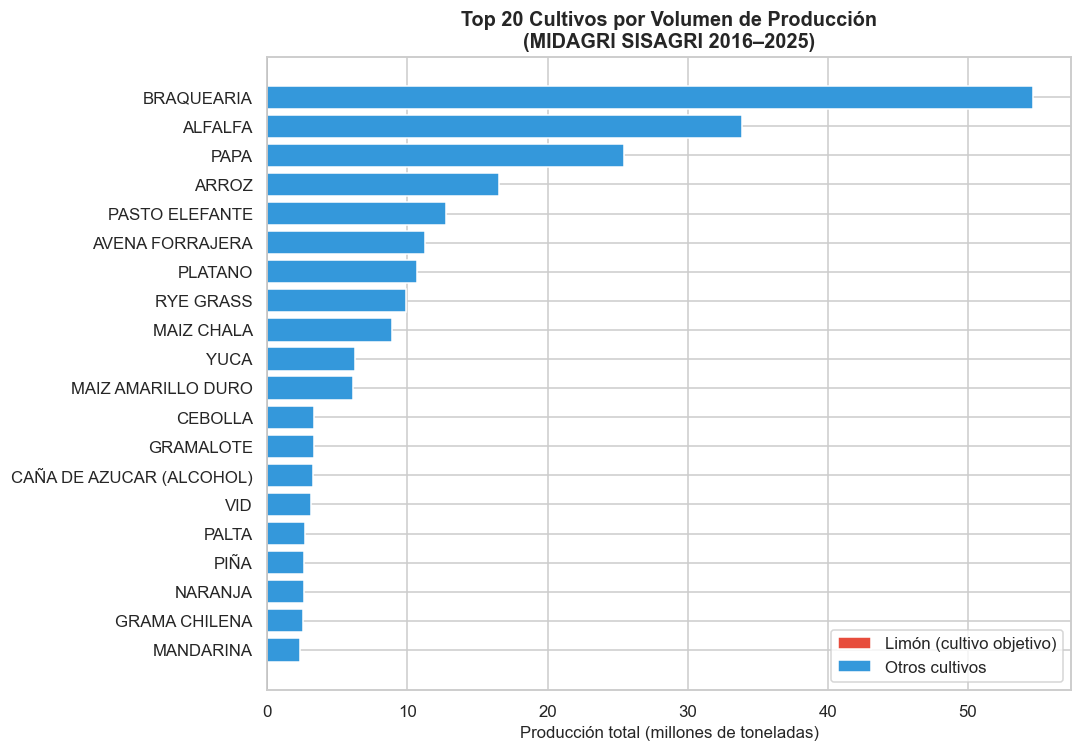

Guardado: pipeline/output/03_eda/midagri_g1_top_cultivos.png


In [5]:
# ============================================================
# GRAFICO 1: Top cultivos por volumen de produccion
# ============================================================
col_prod_name = col_prod[0] if col_prod else df_midagri.columns[2]
col_prod_val  = [c for c in df_midagri.columns if 'PRODUC' in str(c).upper() and df_midagri[c].dtype in ['float64','int64']]
col_prod_val  = col_prod_val[0] if col_prod_val else None

if col_prod_val:
    top_cultivos = (
        df_midagri.groupby(col_prod_name)[col_prod_val]
        .sum().sort_values(ascending=True).tail(20)
    )
    colors = ['#e74c3c' if 'LIMON' in str(c).upper() or 'LIMÓN' in str(c).upper()
              else '#3498db' for c in top_cultivos.index]

    fig, ax = plt.subplots(figsize=(10, 7))
    bars = ax.barh(top_cultivos.index, top_cultivos.values / 1e6, color=colors)
    ax.set_xlabel('Producción total (millones de toneladas)', fontsize=11)
    ax.set_title('Top 20 Cultivos por Volumen de Producción\n(MIDAGRI SISAGRI 2016–2025)', fontsize=13, fontweight='bold')
    ax.axvline(0, color='black', linewidth=0.5)

    # Leyenda manual
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#e74c3c', label='Limón (cultivo objetivo)'),
                       Patch(facecolor='#3498db', label='Otros cultivos')]
    ax.legend(handles=legend_elements, loc='lower right')

    plt.tight_layout()
    out_g1 = OUTPUT['eda'] + 'midagri_g1_top_cultivos.png'
    plt.savefig(out_g1, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Guardado: {out_g1}')
else:
    print('No se encontro columna de produccion numerica. Revisar nombres de columnas.')


### Interpretación — Gráfico 1

**Qué muestra:** El ranking de los 20 cultivos con mayor volumen de producción acumulado en el período 2016–2025. El limón aparece destacado en rojo.

**Implicación para el pipeline:** Confirma que el limón tiene suficiente volumen histórico para ser el cultivo objetivo del modelo. La Actividad 5 filtrará exclusivamente las filas de limón del dataset completo.

**Implicación para el modelo:** Un cultivo con alto volumen y presencia constante en múltiples departamentos garantiza series temporales suficientemente largas para entrenar el LSTM-Attention.


## 2.5 Gráfico 2 — Registros por año


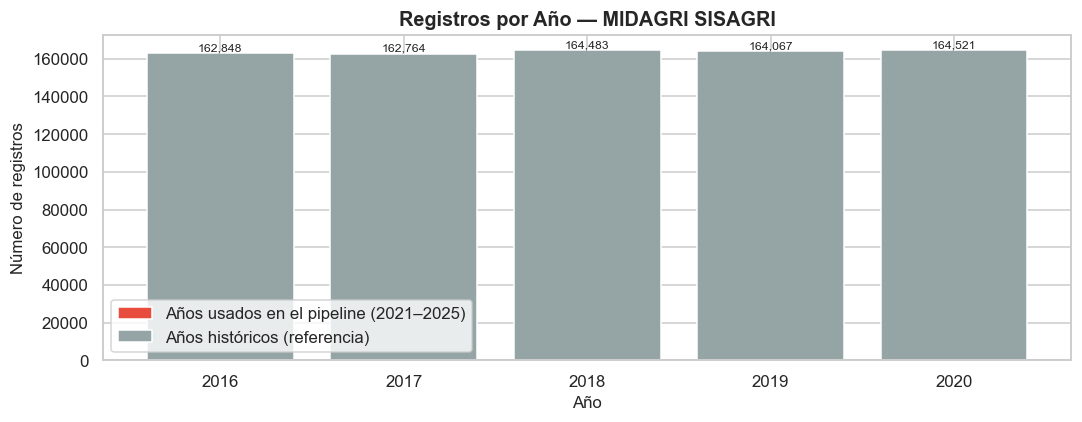

Guardado: pipeline/output/03_eda/midagri_g2_registros_anio.png


In [6]:
# ============================================================
# GRAFICO 2: Registros por año
# ============================================================
if col_anio:
    registros_anio = df_midagri[col_anio[0]].value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(registros_anio.index.astype(str), registros_anio.values,
                  color=['#e74c3c' if int(a) >= 2021 else '#95a5a6' for a in registros_anio.index])
    ax.set_xlabel('Año', fontsize=11)
    ax.set_ylabel('Número de registros', fontsize=11)
    ax.set_title('Registros por Año — MIDAGRI SISAGRI', fontsize=13, fontweight='bold')

    for bar, val in zip(bars, registros_anio.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{val:,}', ha='center', va='bottom', fontsize=8)

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#e74c3c', label='Años usados en el pipeline (2021–2025)'),
                       Patch(facecolor='#95a5a6', label='Años históricos (referencia)')]
    ax.legend(handles=legend_elements)
    plt.tight_layout()
    out_g2 = OUTPUT['eda'] + 'midagri_g2_registros_anio.png'
    plt.savefig(out_g2, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Guardado: {out_g2}')


### Interpretación — Gráfico 2

**Qué muestra:** El número de registros disponibles por año. Los años 2021–2025 (en rojo) son los que usará el pipeline.

**Implicación para el pipeline:** Si algún año tiene significativamente menos registros, puede indicar datos incompletos o que la recolección fue parcial. Esto se investigará en la Actividad 4 (Calidad).

**Implicación para el modelo:** El rango 2021–2025 fue elegido porque coincide con la disponibilidad de las otras fuentes (NASA POWER, INDECI shapefiles, Agraria.pe). Usar datos anteriores a 2021 sin las variables exógenas rompería la consistencia multimodal del dataset.


## 2.6 Gráfico 3 — Cobertura departamento × año (heatmap)


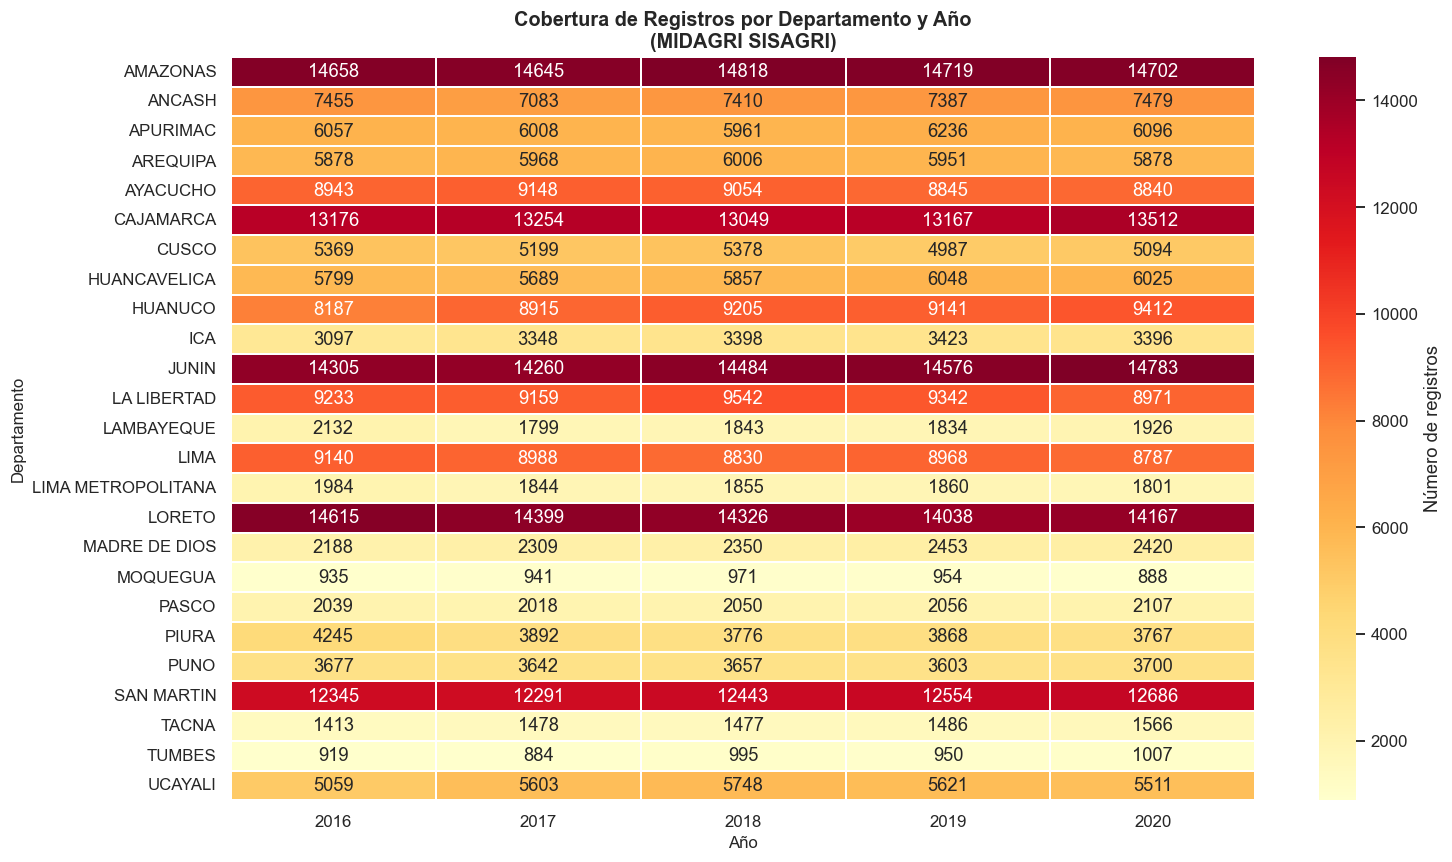

Guardado: pipeline/output/03_eda/midagri_g3_cobertura_heatmap.png


In [7]:
# ============================================================
# GRAFICO 3: Heatmap cobertura departamento x año
# ============================================================
col_dpto = [c for c in df_midagri.columns if 'DPTO' in str(c).upper() or 'DEPART' in str(c).upper()]

if col_anio and col_dpto:
    pivot = df_midagri.groupby([col_dpto[0], col_anio[0]]).size().unstack(fill_value=0)

    fig, ax = plt.subplots(figsize=(14, 8))
    sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd',
                linewidths=0.3, ax=ax, cbar_kws={'label': 'Número de registros'})
    ax.set_title('Cobertura de Registros por Departamento y Año\n(MIDAGRI SISAGRI)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Año', fontsize=11)
    ax.set_ylabel('Departamento', fontsize=11)
    plt.tight_layout()
    out_g3 = OUTPUT['eda'] + 'midagri_g3_cobertura_heatmap.png'
    plt.savefig(out_g3, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Guardado: {out_g3}')
else:
    print('No se encontraron columnas de departamento o año. Revisar nombres.')


### Interpretación — Gráfico 3

**Qué muestra:** La densidad de registros por departamento y año. Celdas en blanco o con valores muy bajos indican cobertura incompleta.

**Implicación para el pipeline:** Los departamentos con celdas vacías en años del rango 2021–2025 serán candidatos a exclusión o imputación en la Actividad 5. Solo se conservarán los departamentos con cobertura continua para garantizar series temporales completas.

**Implicación para el modelo:** El LSTM-Attention requiere series temporales sin huecos. Un departamento con meses faltantes introduce ruido que puede degradar la capacidad predictiva del modelo.


## 2.7 Exportación del raw


In [8]:
# ============================================================
# 2.7 Exportar CSV raw (sin modificaciones)
# ============================================================
out_path = OUTPUT['lectura'] + 'midagri_raw.csv'
df_midagri.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f'Exportado: {out_path}')
print(f'Shape: {df_midagri.shape}')
print(f'Columnas: {df_midagri.columns.tolist()}')
print()
print('[ACTIVIDAD 2 - MIDAGRI] COMPLETADA.')
print('  Siguiente paso: pipeline/fuentes/midagri/actividad_03_eda_midagri.ipynb')


Exportado: pipeline/output/02_lectura/midagri_raw.csv
Shape: (818683, 10)
Columnas: ['anho', 'mes', 'COD_UBIGEO', 'Dpto', 'Prov', 'Dist', 'dsc_Cultivo', 'PRODUCCION(t)', 'COSECHA (ha)', 'MTO_PRECCHAC (S/ x kg)']

[ACTIVIDAD 2 - MIDAGRI] COMPLETADA.
  Siguiente paso: pipeline/fuentes/midagri/actividad_03_eda_midagri.ipynb
